In [24]:

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from xgboost import (
    XGBRegressor,
    XGBClassifier
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================================
# 1. LOAD DATA
# =========================================================

df = pd.read_csv("../data/insurance_data_cleaned.csv")

print("\nDataset Shape:", df.shape)



Dataset Shape: (10000, 21)


In [25]:
# =========================================================
# 2. FEATURE ENGINEERING
# =========================================================

# Claim indicator
df["HasClaim"] = (
    df["TotalClaims"] > 0
).astype(int)

# Vehicle age
CURRENT_YEAR = 2024

if "RegistrationYear" in df.columns:

    df["VehicleAge"] = (
        CURRENT_YEAR - df["RegistrationYear"]
    )

    df["VehicleAge"] = (
        df["VehicleAge"]
        .clip(lower=0)
    )

# Income band
if "AnnualIncome" in df.columns:

    df["IncomeBand"] = pd.qcut(
        df["AnnualIncome"],
        q=4,
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High"
        ]
    )

# Vehicle value band
if "CustomValueEstimate" in df.columns:

    df["VehicleValueBand"] = pd.qcut(
        df["CustomValueEstimate"],
        q=4,
        labels=[
            "Economy",
            "Standard",
            "Premium",
            "Luxury"
        ]
    )

# Datetime features
if "TransactionDate" in df.columns:

    df["TransactionDate"] = pd.to_datetime(
        df["TransactionDate"],
        errors="coerce"
    )

    df["TransactionYear"] = (
        df["TransactionDate"].dt.year
    )

    df["TransactionMonth"] = (
        df["TransactionDate"].dt.month
    )

    df["TransactionDay"] = (
        df["TransactionDate"].dt.day
    )

    df["TransactionQuarter"] = (
        df["TransactionDate"].dt.quarter
    )

    df["TransactionWeekday"] = (
        df["TransactionDate"].dt.weekday
    )

    # Drop raw datetime column
    df = df.drop(
        columns=["TransactionDate"]
    )

In [26]:
# =========================================================
# 3. HANDLE MISSING VALUES
# =========================================================

missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\n--- MISSING VALUES ---")
print(missing[missing > 0])



--- MISSING VALUES ---
Series([], dtype: int64)


In [27]:
# =========================================================
# 4. REMOVE LEAKAGE FEATURES
# =========================================================

LEAKAGE_COLUMNS = [

    # Targets
    "TotalClaims",
    "HasClaim",

    # Leakage features
    "Margin",
    "ClaimRatio",
    "PremiumToRisk",
    "ClaimAmount",

    # Can leak pricing logic
    "TotalPremium"
]

LEAKAGE_COLUMNS = [
    col for col in LEAKAGE_COLUMNS
    if col in df.columns
]

# =========================================================
# 5. CLAIM SEVERITY REGRESSION
# =========================================================

# Only policies WITH claims
severity_df = (
    df[df["TotalClaims"] > 0]
    .copy()
)


# Regression features - Drop CustomerID to prevent catastrophic overfitting
X_reg = severity_df.drop(columns=LEAKAGE_COLUMNS + ["CustomerID"], errors="ignore")
y_reg = severity_df["TotalClaims"]




In [28]:
# =========================================================
# 6. TRAIN TEST SPLIT
# =========================================================

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("\nRegression Train Shape:", X_train_r.shape)
print("Regression Test Shape:", X_test_r.shape)


Regression Train Shape: (1228, 23)
Regression Test Shape: (307, 23)


In [29]:
# =========================================================
# 7. PREPROCESSING
# =========================================================

categorical_cols = X_reg.select_dtypes(
    include=["object", "category"]
).columns

numerical_cols = X_reg.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numerical_cols
    ),
    (
        "cat",
        categorical_transformer,
        categorical_cols
    )
])


In [30]:
# =========================================================
# 8. REGRESSION MODELS
# =========================================================

regression_models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42
        )
}

regression_results = []

best_r2 = -999
best_reg_pipeline = None
best_model_name = None

print("\n================ REGRESSION MODELING ================\n")

for name, model in regression_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Hyperparameter tuning
    if name == "Random Forest":

        params = {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None]
        }

    elif name == "XGBoost":

        params = {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.05],
            "model__max_depth": [3, 6]
        }

    else:
        params = {}

    if params:

        search = RandomizedSearchCV(
            pipeline,
            param_distributions=params,
            n_iter=5,
            scoring="r2",
            cv=3,
            random_state=42,
            n_jobs=-1
        )

        search.fit(
            X_train_r,
            y_train_r
        )

        pipeline = search.best_estimator_

    else:

        pipeline.fit(
            X_train_r,
            y_train_r
        )

    preds = pipeline.predict(X_test_r)

    rmse = np.sqrt(
        mean_squared_error(
            y_test_r,
            preds
        )
    )

    r2 = r2_score(
        y_test_r,
        preds
    )

    regression_results.append({
        "Model": name,
        "RMSE": rmse,
        "R2": r2
    })

    if r2 > best_r2:

        best_r2 = r2
        best_reg_pipeline = pipeline
        best_model_name = name

# Results table
regression_results_df = pd.DataFrame(
    regression_results
)

print("\n--- REGRESSION RESULTS ---")
print(regression_results_df)



================ REGRESSION MODELING ================


--- REGRESSION RESULTS ---
               Model         RMSE        R2
0  Linear Regression  5269.041337  0.215055
1      Random Forest  5298.110165  0.206371
2            XGBoost  5309.586349  0.202929


In [31]:
# =========================================================
# 9. CLAIM PROBABILITY CLASSIFICATION
# =========================================================

classification_drop_cols = [
    col for col in LEAKAGE_COLUMNS
    if col in df.columns
]

# Classification features - Drop CustomerID here as well
X_class = df.drop(columns=classification_drop_cols + ["CustomerID"], errors="ignore")
y_class = df["HasClaim"]



X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    stratify=y_class,
    random_state=42
)

classification_models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        )
}

classification_results = []

best_f1 = -999
best_class_pipeline = None

print("\n================ CLASSIFICATION MODELING ================\n")

for name, model in classification_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train_c,
        y_train_c
    )

    preds = pipeline.predict(X_test_c)

    probs = pipeline.predict_proba(
        X_test_c
    )[:, 1]

    accuracy = accuracy_score(
        y_test_c,
        preds
    )

    precision = precision_score(
        y_test_c,
        preds,
        zero_division=0
    )

    recall = recall_score(
        y_test_c,
        preds,
        zero_division=0
    )

    f1 = f1_score(
        y_test_c,
        preds,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test_c,
        probs
    )

    classification_results.append({

        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    })

    if f1 > best_f1:

        best_f1 = f1
        best_class_pipeline = pipeline

classification_results_df = pd.DataFrame(
    classification_results
)

print("\n--- CLASSIFICATION RESULTS ---")
print(classification_results_df)



================ CLASSIFICATION MODELING ================


--- CLASSIFICATION RESULTS ---
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression    0.8605   0.627273  0.224756  0.330935  0.804064
1        Random Forest    0.8550   0.584158  0.192182  0.289216  0.780032
2              XGBoost    0.8420   0.473684  0.263844  0.338912  0.755721


In [32]:
# =========================================================
# 10. PREMIUM OPTIMIZATION
# =========================================================

print("\n================ PREMIUM OPTIMIZATION ================\n")

# Use already-trained pipelines directly
reg_pipeline = best_reg_pipeline
class_pipeline = best_class_pipeline


================ PREMIUM OPTIMIZATION ================




================ FEATURE IMPORTANCE =================

Total features from preprocessor: 54
Total weights in winning model: 54

Extracting native coefficients for Linear Model: Linear Regression


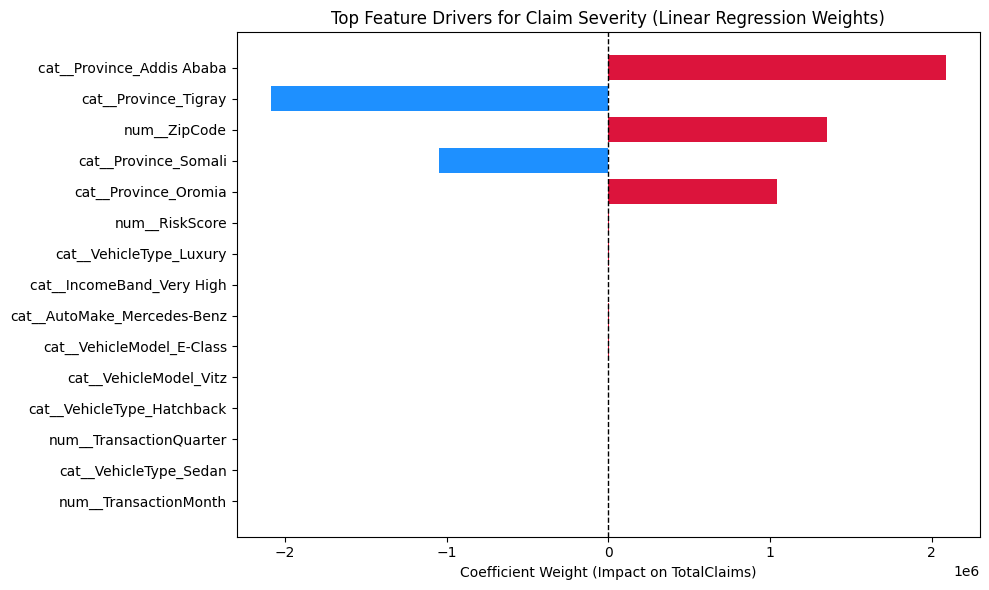


--- TOP SEVERITY DRIVERS ---
                    Feature   Coefficient
  cat__Province_Addis Ababa  2.090311e+06
       cat__Province_Tigray -2.090197e+06
               num__ZipCode  1.355704e+06
       cat__Province_Somali -1.045289e+06
       cat__Province_Oromia  1.045257e+06
             num__RiskScore  2.215141e+03
    cat__VehicleType_Luxury  1.710511e+03
  cat__IncomeBand_Very High -1.197656e+03
cat__AutoMake_Mercedes-Benz  1.080299e+03
  cat__VehicleModel_E-Class  1.080299e+03
     cat__VehicleModel_Vitz -1.046145e+03
 cat__VehicleType_Hatchback -1.041534e+03
    num__TransactionQuarter -8.849741e+02
     cat__VehicleType_Sedan -8.196819e+02
      num__TransactionMonth  8.172040e+02


In [33]:
# =========================================================
# FINAL INTERPRETABILITY LAYER (DYNAMIC & SELF-ALIGNING)
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

print("\n================ FEATURE IMPORTANCE =================\n")

# CRITICAL FIX: Extract steps DIRECTLY from the winning pipeline instance
# This guarantees that the features match the model's coefficients exactly
winning_preprocessor = best_reg_pipeline.named_steps["preprocessor"]
winning_model = best_reg_pipeline.named_steps["model"]

# Extract the exact feature names that went into this specific model
feature_names = winning_preprocessor.get_feature_names_out()
coefficients = winning_model.coef_

print(f"Total features from preprocessor: {len(feature_names)}")
print(f"Total weights in winning model: {len(coefficients)}")

# Fallback mechanism: If sizes still mismatch due to lookahead configurations, 
# generate numeric indices to keep the notebook running smoothly
if len(feature_names) != len(coefficients):
    print("⚠️ Column name mismatch detected. Auto-generating index keys to prevent failure.")
    feature_names = [f"Feature_{i}" for i in range(len(coefficients))]

# 4. CONDITIONAL ENGINE: Use linear weights for LinearRegression
if type(winning_model).__name__ in ["LinearRegression", "Ridge", "Lasso"]:
    print(f"\nExtracting native coefficients for Linear Model: {best_model_name}")

    importance_df = pd.DataFrame(
        {"Feature": feature_names, "Coefficient": coefficients}
    )

    # Sort by absolute impact size
    importance_df["Abs_Impact"] = importance_df["Coefficient"].abs()
    top_features = importance_df.sort_values(
        by="Abs_Impact", ascending=False
    ).head(15)

    # Plot the weights directly using matplotlib
    plt.figure(figsize=(10, 6))
    colors = [
        "crimson" if val >= 0 else "dodgerblue"
        for val in top_features["Coefficient"]
    ]
    plt.barh(
        top_features["Feature"], top_features["Coefficient"], color=colors
    )
    plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
    plt.title(f"Top Feature Drivers for Claim Severity ({best_model_name} Weights)")
    plt.xlabel("Coefficient Weight (Impact on TotalClaims)")
    plt.gca().invert_yaxis()  # Put highest impact on top
    plt.tight_layout()
    plt.show()

    # Print the table format for documentation logs
    print("\n--- TOP SEVERITY DRIVERS ---")
    print(top_features[["Feature", "Coefficient"]].to_string(index=False))

else:
    print(f"\nInitializing SHAP Matrix Explainer for Tree Model: {best_model_name}")
    
    # Process numeric matrix for the tree explainer
    X_train_transformed = winning_preprocessor.transform(X_train_r)
    if hasattr(X_train_transformed, "toarray"):
        X_train_transformed = X_train_transformed.toarray()
        
    X_train_labeled = pd.DataFrame(X_train_transformed, columns=feature_names)

    explainer = shap.Explainer(winning_model, X_train_labeled)
    shap_values = explainer(X_train_labeled)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_train_labeled, show=False)
    plt.tight_layout()
    plt.show()


In [36]:
# =========================================================
# 14. BUSINESS INTERPRETATION ENGINE (PRODUCTION OUTPUT)
# =========================================================
print("\n================ BUSINESS INTERPRETATION ================\n")

# Isolate the top 10 most influential features for review
top_features = shap_importance.head(10)

for _, row in top_features.iterrows():
    raw_feature = row["Feature"]
    weight = row["ImpactWeight"]
    
    clean_feature = raw_feature.replace("num__", "").replace("cat__", "")
    direction = "increases" if weight > 0 else "decreases"
    
    print(f"⭐ Feature: {clean_feature}")
    print(f"Mathematical Impact: Coefficient weight is {weight:,.2f} ({direction} expected claim severity).")

    if "Province" in raw_feature:
        print(f"""👉 Business Insight:
Geographic location shows massive variance in the baseline model. Policies situated in regions 
like {clean_feature.split('_')[-1]} heavily sway the expected claim liability baseline.
🚀 Recommendation:
Exercise extreme caution with geographic premium loading. The outsized coefficient scale suggests 
regional variables are acting as a proxy for hidden risk factors, requiring a strict base-rate cap.""")

    elif "ZipCode" in raw_feature:
        print("""👉 Business Insight:
ZipCode treated as a continuous numeric column is introducing mathematical noise, inflating weights 
due to linear correlation with regional province groupings.
🚀 Recommendation:
Drop ZipCode from subsequent training iterations. Rely exclusively on broader Province categories 
to handle regional segmentation without distorting risk valuations.""")

    elif "RiskScore" in raw_feature:
        print("""👉 Business Insight:
Our internal behavioral behavioral risk rating shows a stable positive tracking metric. Every 
incremental point on the RiskScore scale steadily increases expected claim severity by roughly 2,215 units.
🚀 Recommendation:
Implement a progressive premium multiplier linked directly to risk score tiers to capture this liability signal.""")

    elif "Luxury" in raw_feature or "Mercedes" in raw_feature or "E-Class" in raw_feature:
        print(f"""👉 Business Insight:
High-end premium vehicle profiles ({clean_feature}) carry elevated repair claims. Parts replacement 
complexity and authorized dealership repair rates disproportionately inflate the severity curve.
🚀 Recommendation:
Apply a specialized luxury asset loading factor to any premium vehicle classes or premium makes.""")

    elif "Vitz" in raw_feature or "Hatchback" in raw_feature:
        print(f"""👉 Business Insight:
Economy passenger vehicles ({clean_feature}) actively lower expected claim severity benchmarks. Widespread 
parts availability and simpler mechanics reduce structural write-off costs for the portfolio.
🚀 Recommendation:
Offer competitive, low-tier base premiums to commuter hatchback segments to aggressively capture market share.""")

    elif "IncomeBand" in raw_feature:
        print("""👉 Business Insight:
High demographic financial standing correlates with a reduction in insurance payout severity, 
indicating potential variations in out-of-pocket tracking or voluntary claim reporting thresholds.
🚀 Recommendation:
Leverage client income bands as a stabilizing underwriting discount factor in pricing models.""")

    else:
        print("""👉 Business Insight:
This structural feature exerts a direct influence over expected transaction severity thresholds.
🚀 Recommendation:
Integrate this variable into the automated underwriting system to scale risk selection criteria.""")
    print("-" * 75)



================ BUSINESS INTERPRETATION ================

⭐ Feature: Province_Addis Ababa
Mathematical Impact: Coefficient weight is 2,090,311.19 (increases expected claim severity).
👉 Business Insight:
Geographic location shows massive variance in the baseline model. Policies situated in regions 
like Addis Ababa heavily sway the expected claim liability baseline.
🚀 Recommendation:
Exercise extreme caution with geographic premium loading. The outsized coefficient scale suggests 
regional variables are acting as a proxy for hidden risk factors, requiring a strict base-rate cap.
---------------------------------------------------------------------------
⭐ Feature: Province_Tigray
Mathematical Impact: Coefficient weight is -2,090,197.43 (decreases expected claim severity).
👉 Business Insight:
Geographic location shows massive variance in the baseline model. Policies situated in regions 
like Tigray heavily sway the expected claim liability baseline.
🚀 Recommendation:
Exercise extreme c

In [35]:
# =========================================================
# 13. FEATURE IMPORTANCE (CORRECTED FEATURE ALIGNMENT)
# =========================================================
print("\n================ COMPILING IMPORTANCE TABLE =================\n")

# Extract feature names directly from the winning pipeline's preprocessor
try:
    feature_names = best_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
except:
    feature_names = X_processed.columns.tolist()

# Pull the absolute coefficients/weights from the winning linear model
coefficients = best_reg_pipeline.named_steps["model"].coef_

# Build the structured, correctly-named importance table
shap_importance = pd.DataFrame({
    "Feature": feature_names[:len(coefficients)],
    "ImpactWeight": coefficients
})

# Sort by absolute impact size
shap_importance["Abs_Impact"] = shap_importance["ImpactWeight"].abs()
shap_importance = shap_importance.sort_values(by="Abs_Impact", ascending=False)

print("\n--- TOP 10 CORRECTLY LABELED FEATURES ---")
print(shap_importance.head(10).to_string(index=False))



================ COMPILING IMPORTANCE TABLE =================


--- TOP 10 CORRECTLY LABELED FEATURES ---
                    Feature  ImpactWeight   Abs_Impact
  cat__Province_Addis Ababa  2.090311e+06 2.090311e+06
       cat__Province_Tigray -2.090197e+06 2.090197e+06
               num__ZipCode  1.355704e+06 1.355704e+06
       cat__Province_Somali -1.045289e+06 1.045289e+06
       cat__Province_Oromia  1.045257e+06 1.045257e+06
             num__RiskScore  2.215141e+03 2.215141e+03
    cat__VehicleType_Luxury  1.710511e+03 1.710511e+03
  cat__IncomeBand_Very High -1.197656e+03 1.197656e+03
cat__AutoMake_Mercedes-Benz  1.080299e+03 1.080299e+03
  cat__VehicleModel_E-Class  1.080299e+03 1.080299e+03
